In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("churn_clean.csv")

# Print the shape and the first few rows
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (731, 2)


,Day,Revenue
0,1,0.000000
1,2,0.000793
2,3,0.825542
3,4,0.320332
4,5,1.082554


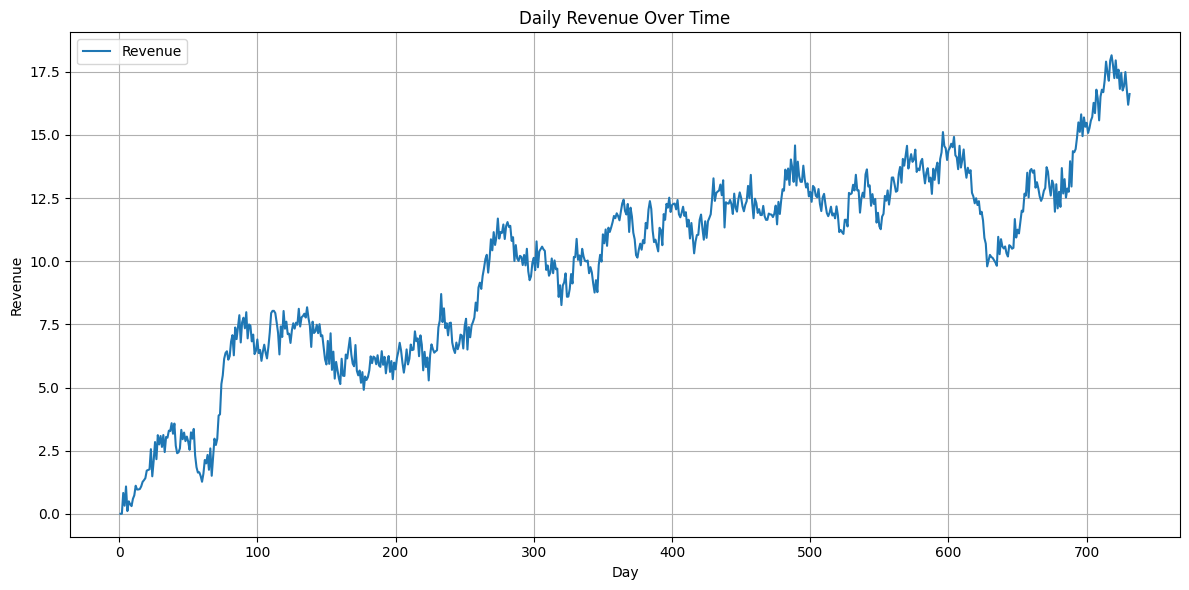

In [2]:
import matplotlib.pyplot as plt

# Set 'Day' as the index
df.set_index('Day', inplace=True)

# Plot the Revenue over time
plt.figure(figsize=(12, 6))
plt.plot(df['Revenue'], label='Revenue')
plt.title('Daily Revenue Over Time')
plt.xlabel('Day')
plt.ylabel('Revenue')
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("figure1_original_revenue.png", dpi=300, bbox_inches='tight')
plt.show()



In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Revenue'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -1.9246121573101809
p-value: 0.32057281507939783


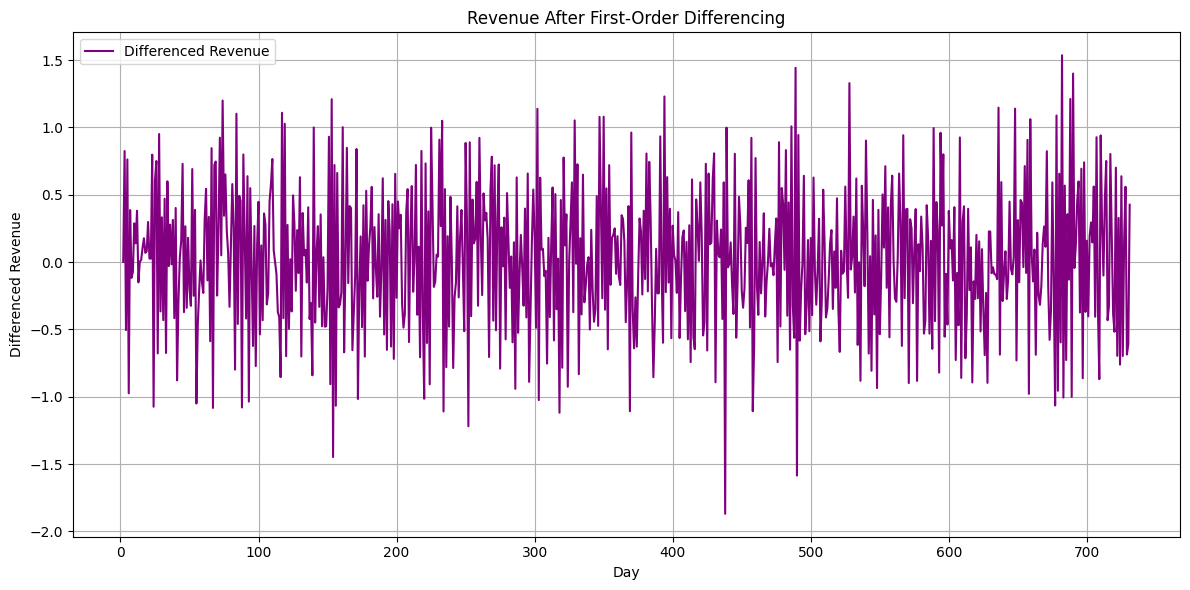

In [4]:
# Get day-to-day revenue change
df['Revenue_diff'] = df['Revenue'].diff()

# Drop first missing value
df_diff = df['Revenue_diff'].dropna()

# Plot the differenced data
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['Revenue_diff'], label='Differenced Revenue', color='purple')
plt.title('Revenue After First-Order Differencing')
plt.xlabel('Day')
plt.ylabel('Differenced Revenue')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("figure2_differenced_revenue.png", dpi=300, bbox_inches='tight')
plt.show()



In [5]:
from statsmodels.tsa.stattools import adfuller

result_diff = adfuller(df_diff)

print("ADF Statistic (Differenced):", result_diff[0])
print("p-value (Differenced):", result_diff[1])
print("Critical Values (Differenced):")
for key, value in result_diff[4].items():
    print(f"   {key}: {value}")


ADF Statistic (Differenced): -44.874527193875984
p-value (Differenced): 0.0
Critical Values (Differenced):
   1%: -3.4393520240470554
   5%: -2.8655128165959236
   10%: -2.5688855736949163


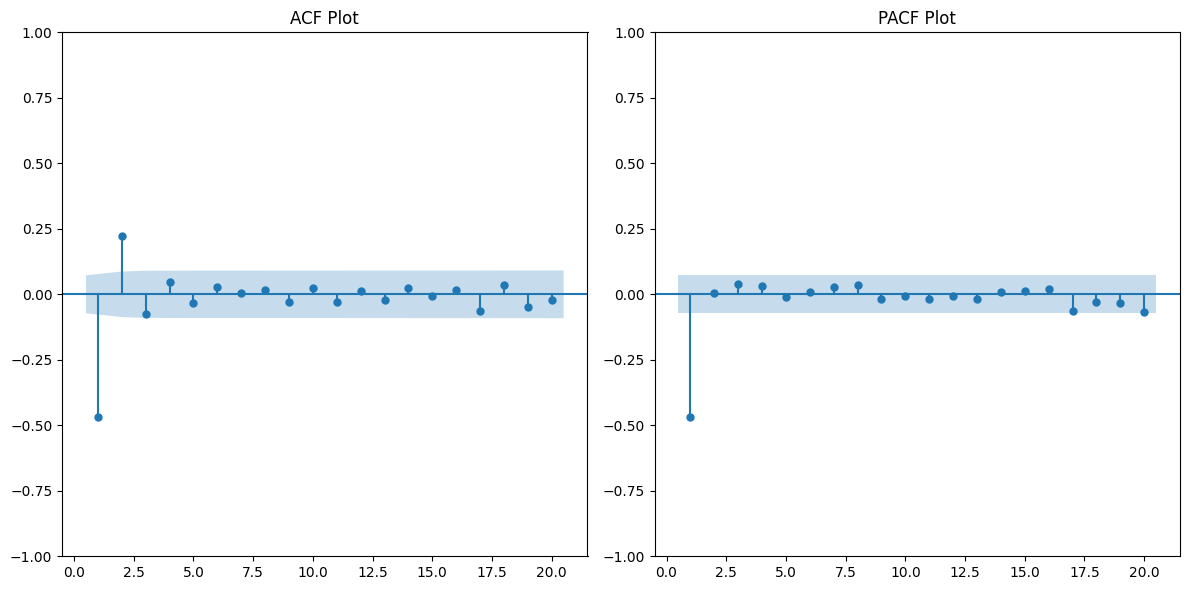

In [6]:
# Look at ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plot_acf(df['Revenue_diff'].dropna(), lags=20, zero=False, ax=plt.gca())
plt.title('ACF Plot')

plt.subplot(1, 2, 2)
plot_pacf(df['Revenue_diff'].dropna(), lags=20, zero=False, ax=plt.gca())
plt.title('PACF Plot')

plt.tight_layout()
plt.savefig("figure3_acf_pacf.png", dpi=300, bbox_inches='tight')
plt.show()



In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model to the original Revenue column

model = ARIMA(df['Revenue'], order=(1, 1, 1))
results = model.fit()

# View summary
print(results.summary())


                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  731
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -490.326
Date:                Mon, 07 Apr 2025   AIC                            986.652
Time:                        17:31:14   BIC                           1000.431
Sample:                             0   HQIC                           991.968
                                - 731                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4804      0.068     -7.063      0.000      -0.614      -0.347
ma.L1          0.0176      0.077      0.227      0.821      -0.134       0.169
sigma2         0.2243      0.013     17.764      0.0

C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [8]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Create an 80/20 train-test split
train_size = int(len(df) * 0.8)
train = df['Revenue'][:train_size]
test = df['Revenue'][train_size:]

# Refit the model on training data only
model = ARIMA(train, order=(1, 1, 1))
results = model.fit()

# Predict for the test set
start = len(train)
end = len(df) - 1
predictions = results.predict(start=start, end=end)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test, predictions))
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 2.17651002522139


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Pytho

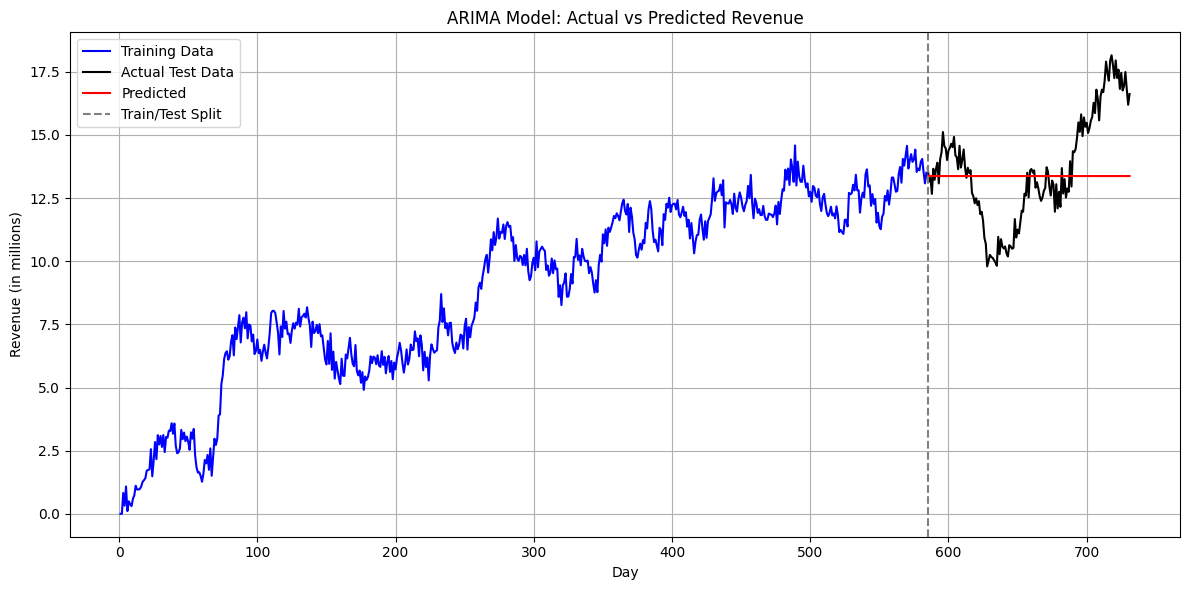

In [9]:
import matplotlib.pyplot as plt

# Align predictions with test index for plotting
predictions.index = test.index

# Plot actual vs predicted revenue
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Training Data', color='blue')
plt.plot(test.index, test, label='Actual Test Data', color='black')
plt.plot(predictions.index, predictions, label='Predicted', color='red')
plt.axvline(x=test.index[0], color='gray', linestyle='--', label='Train/Test Split')
plt.title('ARIMA Model: Actual vs Predicted Revenue')
plt.xlabel('Day')
plt.ylabel('Revenue (in millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("figure4_actual_vs_predicted.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Pytho

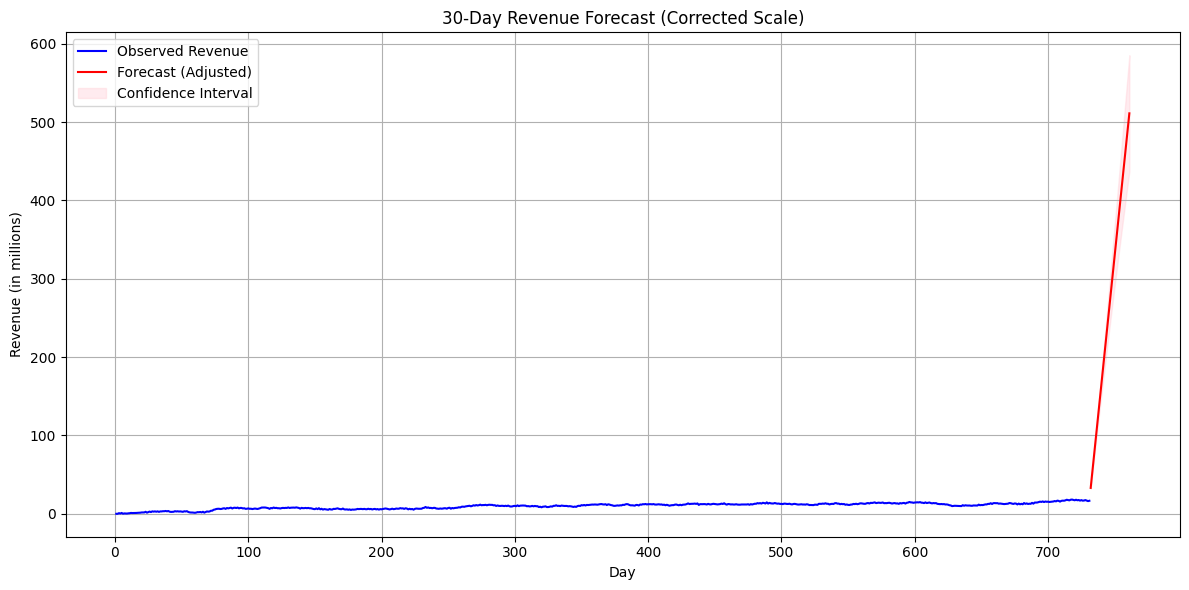

In [10]:
# Refit the model on full data
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Revenue'], order=(1, 1, 1))
results = model.fit()

# Forecast the next 30 days
forecast_obj = results.get_forecast(steps=30)

# Get predicted differences
forecast_diff = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Correct the forecast to original scale
# Start at the last actual revenue value
last_actual = df['Revenue'].iloc[-1]
forecast_values = forecast_diff.cumsum() + last_actual
conf_int_cumsum = conf_int.cumsum() + last_actual

# Fix index for forecast
future_index = range(df.index[-1] + 1, df.index[-1] + 1 + 30)
forecast_values.index = future_index
conf_int_cumsum.index = future_index

# Plot everything correctly
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Revenue'], label='Observed Revenue', color='blue')
plt.plot(forecast_values.index, forecast_values, label='Forecast (Adjusted)', color='red')
plt.fill_between(
    conf_int_cumsum.index,
    conf_int_cumsum.iloc[:, 0],
    conf_int_cumsum.iloc[:, 1],
    color='pink', alpha=0.3, label='Confidence Interval'
)
plt.title('30-Day Revenue Forecast (Corrected Scale)')
plt.xlabel('Day')
plt.ylabel('Revenue (in millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
C:\Users\Crystal\AppData\Local\Programs\Python\Pytho

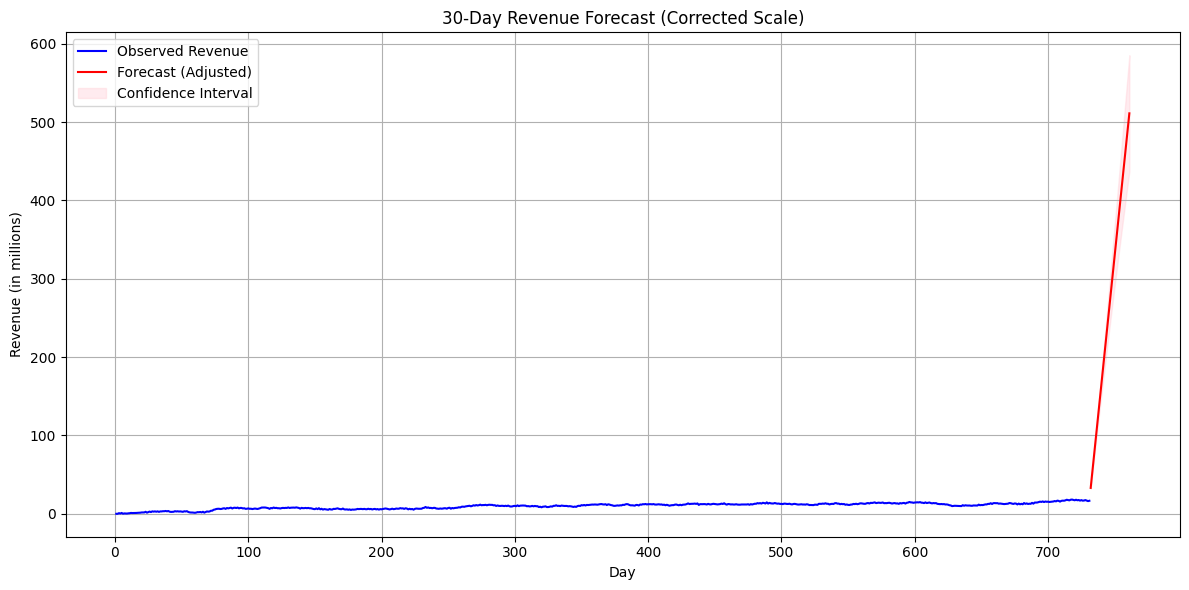

In [11]:
# Refit the model on full data
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['Revenue'], order=(1, 1, 1))
results = model.fit()

# Forecast the next 30 days
forecast_obj = results.get_forecast(steps=30)

# Get predicted differences
forecast_diff = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Correct the forecast to original scale
# Start at the last actual revenue value
last_actual = df['Revenue'].iloc[-1]
forecast_values = forecast_diff.cumsum() + last_actual
conf_int_cumsum = conf_int.cumsum() + last_actual

# Fix index for forecast
future_index = range(df.index[-1] + 1, df.index[-1] + 1 + 30)
forecast_values.index = future_index
conf_int_cumsum.index = future_index

# Plot everything correctly
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Revenue'], label='Observed Revenue', color='blue')
plt.plot(forecast_values.index, forecast_values, label='Forecast (Adjusted)', color='red')
plt.fill_between(
    conf_int_cumsum.index,
    conf_int_cumsum.iloc[:, 0],
    conf_int_cumsum.iloc[:, 1],
    color='pink', alpha=0.3, label='Confidence Interval'
)
plt.title('30-Day Revenue Forecast (Corrected Scale)')
plt.xlabel('Day')
plt.ylabel('Revenue (in millions)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [12]:
# Get the raw predicted differences (before any cumsum)
forecast_obj = results.get_forecast(steps=30)
forecast_raw = forecast_obj.predicted_mean
conf_int_raw = forecast_obj.conf_int()

# Check values
print("Forecast raw (before cumsum):")
print(forecast_raw.head())


Forecast raw (before cumsum):
731    16.418783
732    16.515834
733    16.469209
734    16.491609
735    16.480848
Name: predicted_mean, dtype: float64


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


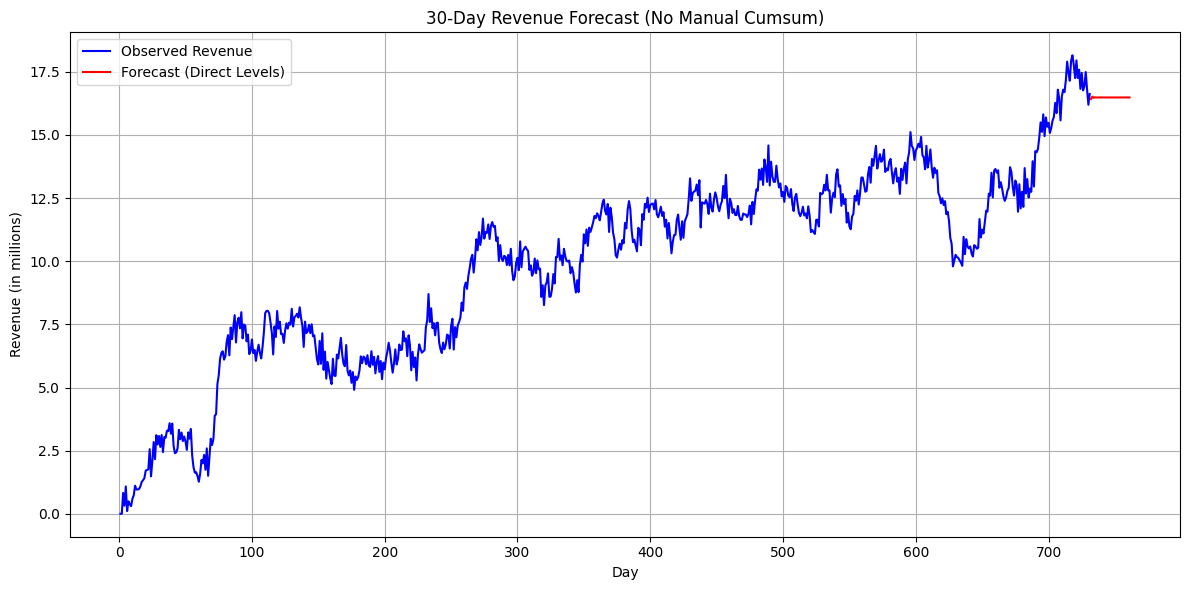

In [13]:
# Forecast using .predict() instead of .get_forecast()
future_steps = 30
start = len(df)
end = start + future_steps - 1

predicted = results.predict(start=start, end=end, typ='levels')

# Generate future day index
future_index = range(df.index[-1] + 1, df.index[-1] + 1 + future_steps)
predicted.index = future_index

# Plot forecast directly
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Revenue'], label='Observed Revenue', color='blue')
plt.plot(predicted.index, predicted, label='Forecast (Direct Levels)', color='red')
plt.title('30-Day Revenue Forecast (No Manual Cumsum)')
plt.xlabel('Day')
plt.ylabel('Revenue (in millions)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("figure5_forecast_with_confidence.png", dpi=300, bbox_inches='tight')
plt.show()


C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Crystal\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


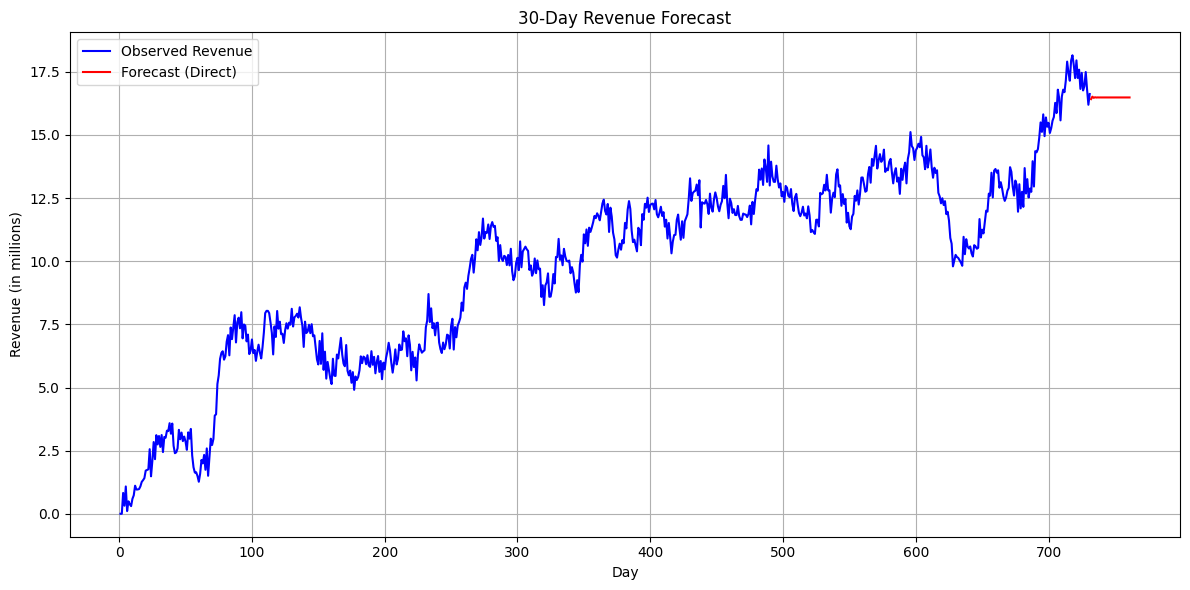

In [14]:
# Predict next 30 days directly in revenue scale
start = len(df)
end = start + 29  # 30 days
forecast_direct = results.predict(start=start, end=end, typ='levels')

# Assign proper future index
future_index = range(df.index[-1] + 1, df.index[-1] + 1 + 30)
forecast_direct.index = future_index

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Revenue'], label='Observed Revenue', color='blue')
plt.plot(forecast_direct.index, forecast_direct, label='Forecast (Direct)', color='red')
plt.title('30-Day Revenue Forecast')
plt.xlabel('Day')
plt.ylabel('Revenue (in millions)')
plt.grid(True)
plt.legend()
plt.tight_layout()

# Save the figure
plt.savefig("figure5_forecast_plot.png", dpi=300)
plt.show()


In [15]:
print("Root Mean Squared Error (RMSE):", rmse)


Root Mean Squared Error (RMSE): 2.17651002522139
